In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
# Seed zapewnia identyczne dane u każdego studenta
np.random.seed(42)
n = 200
dzialy = np.random.choice(['IT', 'Sprzedaz', 'HR', 'Marketing', 'Finanse'], n,
 p=[0.30, 0.25, 0.15, 0.20, 0.10])
staz = np.random.gamma(shape=3, scale=2, size=n).clip(0.5, 20).round(1)
baza = {'IT': 9000, 'Sprzedaz': 7000, 'HR': 6500, 'Marketing': 7500, 'Finanse':
8500}
wynagrodzenie = np.array([
 baza[d] + staz[i] * 300 + np.random.normal(0, 1200)
 for i, d in enumerate(dzialy)
]).clip(4000, 25000).round(-2)
# 5 celowo wstawionych outlierów (błędy danych / kontrakty specjalne)
wynagrodzenie[np.random.choice(n, 5, replace=False)] = np.random.choice(
 [2000, 2500, 35000, 40000, 38000], 5, replace=False
)
df = pd.DataFrame({
 'dzial': dzialy,
 'staz_lat': staz,
 'wynagrodzenie': wynagrodzenie,
 'wiek': (25 + staz + np.random.normal(0, 3, n)).clip(22,
65).round().astype(int),
 'ocena_roczna': np.random.choice([1, 2, 3, 4, 5], n, p=[0.05, 0.10, 0.40,
0.35, 0.10])
})
print(f"Dataset HR: {df.shape[0]} pracowników, {df.shape[1]} kolumn")
print(df.head())
print("\nTypy kolumn:")
print(df.dtypes)

Dataset HR: 200 pracowników, 5 kolumn
       dzial  staz_lat  wynagrodzenie  wiek  ocena_roczna
0   Sprzedaz       3.4         9100.0    27             5
1    Finanse       6.1        12600.0    35             3
2  Marketing       6.3         7700.0    38             3
3         HR       3.3         8200.0    27             4
4         IT      14.0        12400.0    38             4

Typy kolumn:
dzial                str
staz_lat         float64
wynagrodzenie    float64
wiek               int64
ocena_roczna       int64
dtype: object


# Ćwiczenie 1: Statystyki opisowe na danych biznesowych

## 1a. Miary tendencji centralnej

In [12]:
placa = df['wynagrodzenie']
# Uzupełnij: oblicz średnią, medianę i dominantę
srednia = placa.mean()
mediana = placa.median()
dominanta = placa.mode().iloc[0]
print("=== MIARY TENDENCJI CENTRALNEJ ===")
print(f"Średnia: {round(srednia,2)} PLN")
print(f"Mediana: {round(mediana,2)} PLN")
print(f"Dominanta: {round(dominanta,2)} PLN")
# Odpowiedz na pytanie w komentarzu:
# Czy mediana < średnia? Co to mówi o rozkładzie?
# Rozkład jest prawostronny

=== MIARY TENDENCJI CENTRALNEJ ===
Średnia: 9940.0 PLN
Mediana: 9450.0 PLN
Dominanta: 9500.0 PLN


## 1b. Miary rozproszenia

In [ ]:
# Uzupełnij
odch_std = placa.std()
q1 = placa.quantile(0.25) 
q3 = placa.quantile(0.75) 
iqr = q3 - q1
rozstep = placa.max() - placa.min() # max - min
print("=== MIARY ROZPROSZENIA ===")
print(f"Odchylenie std: {odch_std} PLN")
print(f"Q1 (P25): {q1} PLN")
print(f"Q3 (P75): {q3} PLN")
print(f"IQR: {iqr} PLN")
print(f"Rozstęp: {rozstep} PLN")
# Odpowiedz w komentarzu: dlaczego rozstęp jest tak duży?
# 5 outlierów dodanych do datasetu + wysokie odchylenie standardowe

=== MIARY ROZPROSZENIA ===
Odchylenie std: 3979.7224720794125 PLN
Q1 (P25): 8200.0 PLN
Q3 (P75): 10700.0 PLN
IQR: 2500.0 PLN
Rozstęp: 38000.0 PLN


## 1c. Statystyki per dział


In [5]:
dzialy_stats = df.groupby('dzial', observed=True)['wynagrodzenie'].agg([
 'mean', 'median', 'std'
]).round(0).sort_values('median', ascending=False)
dzialy_stats.columns = ['Średnia', 'Mediana', 'Std']
print("=== WYNAGRODZENIA PER DZIAŁ ===")
print(dzialy_stats)

=== WYNAGRODZENIA PER DZIAŁ ===
           Średnia  Mediana     Std
dzial                              
IT         11108.0  10600.0  4145.0
Finanse    10621.0  10400.0  1741.0
Marketing   9476.0   9100.0  4386.0
HR          8354.0   8400.0  1622.0
Sprzedaz    9282.0   8400.0  4428.0


## 1d. Wizualizacja — histogram z miarami centralnymi

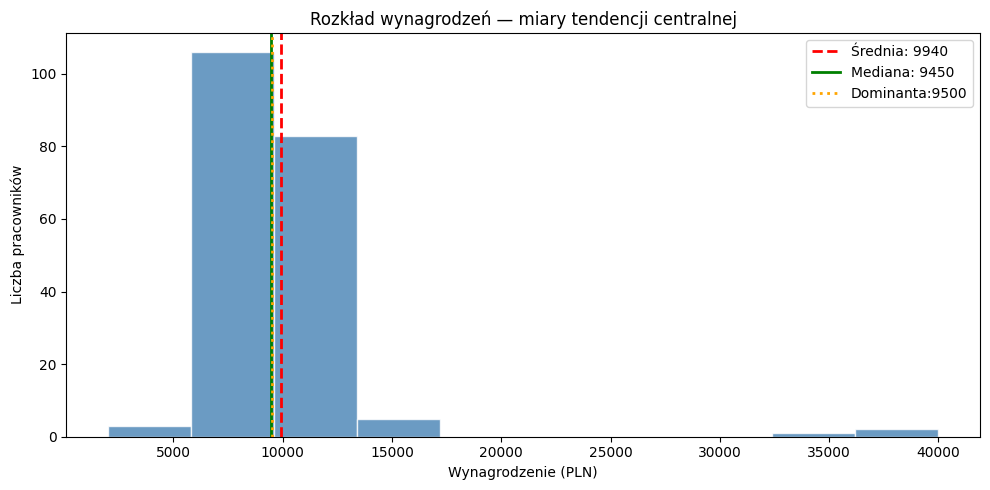

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
# Uzupełnij ___ wartościami:
ax.hist(placa, bins=10, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(srednia, color='red', linestyle='--', lw=2, label=f'Średnia: {round(srednia)}')
ax.axvline(mediana, color='green', linestyle='-', lw=2, label=f'Mediana: {round(mediana)}')
ax.axvline(dominanta, color='orange', linestyle=':', lw=2, label=f'Dominanta:{round(dominanta)}')
# Uwaga: dominanta i mediana mogą się prawie pokryć — to też informacja
ax.set_title('Rozkład wynagrodzeń — miary tendencji centralnej')
ax.set_xlabel('Wynagrodzenie (PLN)')
ax.set_ylabel('Liczba pracowników')
ax.legend()
plt.tight_layout()
plt.show()
plt.close()

# Ćwiczenie 2: Analiza korelacji

## 2a. Korelacja Pearsona: staż vs wynagrodzenie


In [14]:
# Uzupełnij: oblicz korelację Pearsona
# stats.pearsonr() zwraca (r, p_value)
r, p_value = stats.pearsonr(df['staz_lat'], df['wynagrodzenie'])
print(f"Korelacja Pearsona (staż–wynagrodzenie):")
print(f" r = {r:.4f}")
print(f" p = {p_value:.4f}")
print(f" Interpretacja: {'istotna' if p_value < 0.05 else 'nieistotna'} statystycznie")


Korelacja Pearsona (staż–wynagrodzenie):
 r = 0.3198
 p = 0.0000
 Interpretacja: istotna statystycznie


## 2b. Korelacja Spearmana — porównanie

In [15]:
# Oblicz korelację Spearmana (odporniejsza na outliery)
rho, p_rho = stats.spearmanr(df['staz_lat'], df['wynagrodzenie'])
print(f"Korelacja Spearmana (staż–wynagrodzenie):")
print(f" rho = {rho:.4f}")
print(f" p = {p_rho:.4f}")
print(f"\nPorównanie: Pearson r={r:.3f} vs Spearman rho={rho:.3f}")
print(f"Różnica: {abs(rho - r):.3f} — {'duże' if abs(rho-r) > 0.1 else 'małe'} rozbieżności")
# Odpowiedz w komentarzu: dlaczego Spearman jest wyższy niż Pearson?
# Spearman mierzy kiedy x rośnie to y NIE SPADA a pearson mierzy kiedy x rośnie to y również rośnie

Korelacja Spearmana (staż–wynagrodzenie):
 rho = 0.5219
 p = 0.0000

Porównanie: Pearson r=0.320 vs Spearman rho=0.522
Różnica: 0.202 — duże rozbieżności


## 2c. Oblicz pełną macierz korelacji Pearsona

Macierz korelacji Pearsona:
               staz_lat  wynagrodzenie   wiek  ocena_roczna
staz_lat          1.000          0.320  0.756        -0.057
wynagrodzenie     0.320          1.000  0.219        -0.054
wiek              0.756          0.219  1.000        -0.081
ocena_roczna     -0.057         -0.054 -0.081         1.000


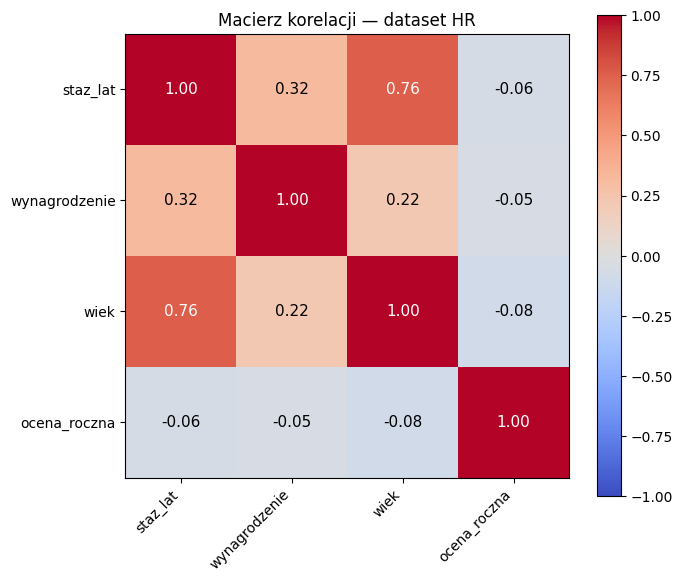

In [4]:
corr = df[['staz_lat', 'wynagrodzenie', 'wiek', 'ocena_roczna']].corr()
print("Macierz korelacji Pearsona:")
print(corr.round(3))
# Wizualizacja — heatmapa (matplotlib już zaimportowany w Setupie)
fig, ax = plt.subplots(figsize=(7, 6))
# Rysuj heatmapę ręcznie (bez seaborn)
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)
# Dodaj wartości w komórkach
for i in range(len(corr)):
 for j in range(len(corr.columns)):
    ax.text(j, i, f'{corr.values[i, j]:.2f}', ha='center', va='center', fontsize=11, color='black' if abs(corr.values[i,j]) < 0.7 else 'white')
ax.set_title('Macierz korelacji — dataset HR')
plt.tight_layout()
plt.show()
plt.close()

## 2d. Korelacja: marketing spend vs revenue

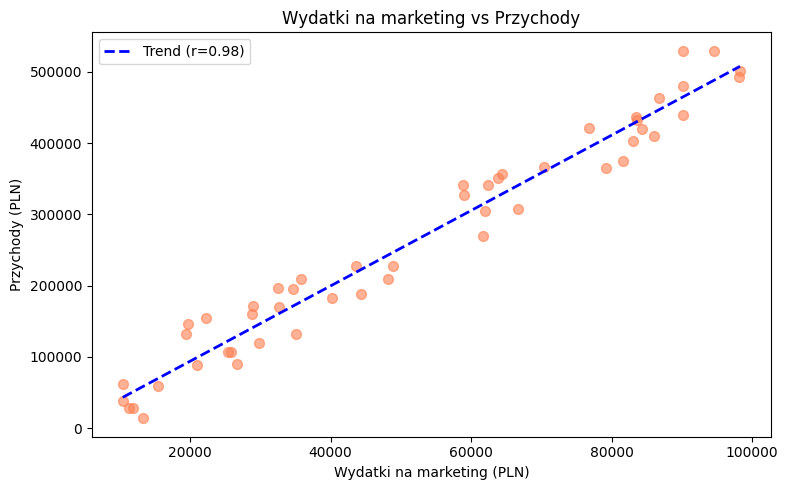

Marketing spend vs Revenue: r = 0.9806, p = 1.22e-35


In [5]:
np.random.seed(100)
n_mkt = 50
marketing_spend = np.random.uniform(10000, 100000, n_mkt)
revenue = marketing_spend * 5.2 + np.random.normal(0, 30000, n_mkt)
revenue = revenue.clip(0)
# Oblicz korelację Pearsona
r_mkt, p_mkt = stats.pearsonr(marketing_spend, revenue)

# Scatter plot z linią trendu
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(marketing_spend, revenue, alpha=0.6, color='coral', s=50)
# Dodaj linię trendu (polyfit stopień 1)
z = np.polyfit(marketing_spend, revenue, 1)
p_fit = np.poly1d(z)
x_line = np.linspace(marketing_spend.min(), marketing_spend.max(), 100)
ax.plot(x_line, p_fit(x_line), 'b--', lw=2, label=f'Trend (r={r_mkt:.2f})')
ax.set_title('Wydatki na marketing vs Przychody')
ax.set_xlabel('Wydatki na marketing (PLN)')
ax.set_ylabel('Przychody (PLN)')
ax.legend()
plt.tight_layout()
plt.show()
plt.close()
print(f"Marketing spend vs Revenue: r = {r_mkt:.4f}, p = {p_mkt:.2e}")

# Ćwiczenie 3: Pełna analiza statystyczna datasetu HR

## 3a. scipy.stats.describe — szybki przegląd rozkładu

In [ ]:
# Użyj: stats.describe(df['wynagrodzenie'])
stats.describe(df['wynagrodzenie'])
# Wyświetl: nobs, min, max, mean, variance, skewness, kurtosis
print(f'nobs: {stats.describe(df['wynagrodzenie']).nobs}')
print(f'min: {df['wynagrodzenie'].min()}')
print(f'max:{df['wynagrodzenie'].max()}')
print(f'mean: {df['wynagrodzenie'].mean()}')
print(f'wariancja :{stats.describe(df['wynagrodzenie']).variance}')
print(f'skewness :{stats.describe(df['wynagrodzenie']).skewness}')
print(f'kurtosis :{stats.describe(df['wynagrodzenie']).kurtosis}')
# Dodaj interpretację w komentarzu lub print()
# Wynagrodzenie jest w przedziale od 2000 do 40000 skewness dodatni oznacza prawostronną nierówność przedziału (większość pracowników zarabia poniżej średniej)
# ogromna kurtoza oznacza wysokie skumulowanie wynagrodzeń około średniej nieznaczna część pracowników zarabia dużo więcej lub mniej od średniej. 

nobs: 200
min: 2000.0
max:40000.0
mean: 9940.0
wariancja :15838190.954773868
skewness :5.102436656481927
kurtosis :34.15940740325192


## 3b. Analiza percentylowa

In [10]:
# Użyj: np.percentile(df['wynagrodzenie'], [10, 25, 50, 75, 90, 95, 99])
tempxd = ['P10:','P25:','P50:','P75:','P90:','P95:','P99:']
precentyle = np.percentile(df['wynagrodzenie'], [10, 25, 50, 75, 90, 95, 99])
# Wyświetl jako tabelę: "P10: 7 190 PLN", "P50: 9 450 PLN" itd.
for i in range(len(tempxd)):
    print(f'{tempxd[i]} {precentyle[i]: .0f} PLN')

P10:  7190 PLN
P25:  8200 PLN
P50:  9450 PLN
P75:  10700 PLN
P90:  12310 PLN
P95:  13105 PLN
P99:  35030 PLN


## 3c. Analiza per dział — pełna tabela

In [32]:
IQR: lambda x: x.quantile(0.75) - x.quantile(0.25)
df.groupby('dzial', observed=True)['wynagrodzenie'].agg(['mean', 'median', 'std', 'min', 'max']).sort_values(by='median',ascending=False)

,mean,median,std,min,max
dzial,,,,,
IT,11107.575758,10600.0,4144.813649,2500.0,40000.0
Finanse,10621.052632,10400.0,1741.193380,8300.0,16200.0
Marketing,9475.609756,9100.0,4386.386924,2000.0,35000.0
HR,8354.166667,8400.0,1622.123988,4500.0,10800.0
Sprzedaz,9282.000000,8400.0,4428.096288,5900.0,38000.0


## 3d. Wizualizacja — boxplot per dział

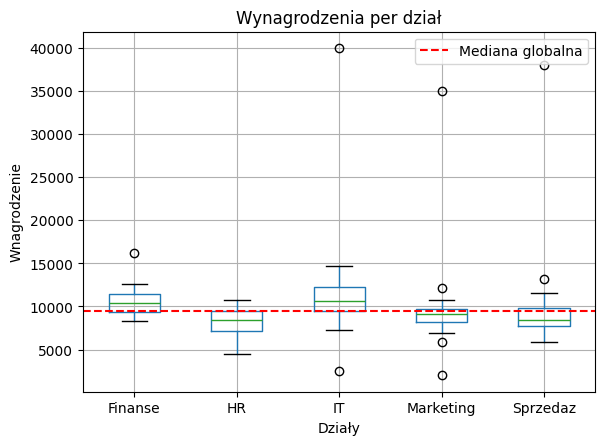

In [53]:
ax = df.boxplot(column='wynagrodzenie', 
           by='dzial',
           ylabel='Wnagrodzenie',
           xlabel='Działy')
ax.axhline(df['wynagrodzenie'].median(),
           color='red',
           linestyle='--',
           label='Mediana globalna')
ax.set_title('Wynagrodzenia per dział')
plt.suptitle('')
ax.legend()

## 3e. scipy.stats.describe — per dział IT i HR

In [ ]:
for d in ['IT', 'HR']:
 podzb = df[df['dzial'] == d]['wynagrodzenie']
 opis = stats.describe(podzb)
 print(f"\n{d} (n={opis.nobs}):")
 print(f" Skośność: {opis.skewness:.3f}")
 print(f" Kurtoza: {opis.kurtosis: .0f}")

# W dziale HR jest nieznaczna Skośność i kurtoza < 3 wszyscy zarabiają podobne pieniądze
# W IT dane są dziwne zapewne w nim są outliery


IT (n=66):
 Skośność: 5.067
 Kurtoza:  34

HR (n=24):
 Skośność: -0.460
 Kurtoza: -0


# Ćwiczenie 4: Wykrywanie outlierów

## 4a. Wykrywanie outlierów metodą IQR

In [55]:
# Oblicz granice IQR
q1 = df['wynagrodzenie'].quantile(0.25)
q3 = df['wynagrodzenie'].quantile(0.75)
iqr = q3 - q1
dolna = q1 - 1.5 * iqr
gorna = q3 + 1.5 * iqr
print(f"IQR granice: [{dolna:,.0f} PLN, {gorna:,.0f} PLN]")
# Wykryj outlierów
maska_iqr = (df['wynagrodzenie'] < dolna) | (df['wynagrodzenie'] > gorna)
outliery = df[maska_iqr]
print(f"Liczba outlierów: {maska_iqr.sum()} z {len(df)}")
print("\nSzczegóły outlierów:")
print(outliery[['dzial', 'staz_lat', 'wynagrodzenie']].to_string())

IQR granice: [4,450 PLN, 14,450 PLN]
Liczba outlierów: 7 z 200

Szczegóły outlierów:
         dzial  staz_lat  wynagrodzenie
51   Marketing       3.1         2000.0
61          IT      10.6        14700.0
79          IT       6.3        40000.0
83          IT       8.8         2500.0
138   Sprzedaz      13.8        38000.0
154    Finanse      15.3        16200.0
183  Marketing       3.7        35000.0


## 4b. Wykrywanie outlierów metodą z-score

In [56]:
# Oblicz z-score: stats.zscore()
z_scores = np.abs(stats.zscore(df['wynagrodzenie']))
maska_z = z_scores > 3.0
outliery_z = df[maska_z]
print(f"Outlierzy z-score (|z| > 3.0): {maska_z.sum()} obserwacji")
print(outliery_z[['dzial', 'staz_lat', 'wynagrodzenie']].to_string())

Outlierzy z-score (|z| > 3.0): 3 obserwacji
         dzial  staz_lat  wynagrodzenie
79          IT       6.3        40000.0
138   Sprzedaz      13.8        38000.0
183  Marketing       3.7        35000.0


## 4c. Wpływ outlierów na statystyki

In [ ]:
bez_outlierow = df[~maska_iqr]['wynagrodzenie']
z_outlierami = df['wynagrodzenie']
print(f"{'Miara':<20} {'Z outlierami':>15} {'Bez outlierów':>15} {'Zmiana':>10}")
print("-" * 62)
for nazwa, f_z, f_bez in [
 ('Średnia', z_outlierami.mean(), bez_outlierow.mean()),
 ('Mediana', z_outlierami.median(), bez_outlierow.median()),
 ('Std', z_outlierami.std(), bez_outlierow.std()),
]:
 zmiana = f_z - f_bez
 print(f"{nazwa:<20} {f_z:>15,.0f} {f_bez:>15,.0f} {zmiana:>+10,.0f}")